# PBMC 10k: Rust vs Python Inference Speed

Benchmarks `fit_all_grid_points` on `processed_pbmc_10k_raw.h5ad` (10,997 cells × 36,601 genes)
comparing the Rust PSS fast-path against the pure-Python baseline.

**Model:** Bursty + Poisson  
Three sweeps:
1. **Core-count sweep** — fixed 50 genes, vary `num_cores` 1→8
2. **Gene-count sweep** — fixed `num_cores=4`, vary genes 25→200
3. **Cell-count sweep** — fixed `num_cores=4`, 50 genes, subsample cells 100→10k

Inference uses a reduced 3×4 sampling grid (12 points) and 10 optimizer iterations
to keep runtimes practical while preserving relative differences.

## Setup

In [1]:
import sys, os, time, warnings, tempfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import anndata as ad

sys.path.insert(0, 'src/monod')
warnings.filterwarnings('ignore')

import cme_toolbox
import inference
from cme_toolbox import CMEModel, _HAS_RUST
from extract_data import extract_data
from inference import InferenceParameters, searchdata_from_adata

print(f'Rust extension available: {_HAS_RUST}')
print(f'Logical CPUs: {os.cpu_count()}')

Rust extension available: True
Logical CPUs: 12


## Constants and helpers

In [2]:
H5AD_PATH = 'example_h5ad/processed_pbmc_10k_raw.h5ad'
MODEL     = CMEModel('Bursty', 'Poisson')

# Reduced grid and iteration count to keep runtimes practical.
GRADIENT_PARAMS_BASE = {
    'max_iterations': 10,
    'init_pattern': 'moments',
    'num_restarts': 1,
}
GRIDSIZE = [3, 4]  # 12 sampling points instead of the default 6×7=42

def time_full_pipeline(h5ad_path, n_genes, num_cores, has_rust, rng_seed=0):
    """Time the full pipeline: extract_data + fit_all_grid_points."""
    gp = dict(GRADIENT_PARAMS_BASE, num_gene_cores=num_cores)
    cme_toolbox._HAS_RUST = has_rust
    inference._HAS_RUST   = has_rust
    np.random.seed(rng_seed)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        t0 = time.perf_counter()
        adata = extract_data(
            h5ad_path, MODEL,
            dataset_name='pbmc_bench',
            modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
            n_genes=n_genes, hist_type='unique', viz=False,
        )
        sd = searchdata_from_adata(adata)
        ip = InferenceParameters('pbmc_bench', MODEL,
                                 use_lengths=False, gradient_params=gp,
                                 gridsize=GRIDSIZE, save=False)
        ip.fit_all_grid_points(sd, num_cores=num_cores, save=False)
        elapsed = time.perf_counter() - t0
    cme_toolbox._HAS_RUST = _HAS_RUST
    inference._HAS_RUST   = _HAS_RUST
    return elapsed


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


## 1. Core-count sweep

Fixed 50 genes; vary `num_cores`.

In [3]:
CORE_COUNTS  = [1, 2, 4, 8]
N_GENES_CORE = 50

core_results = {}

for nc in CORE_COUNTS:
    for has_rust in (True, False):
        print(f'cores={nc}, rust={has_rust} ...', end=' ', flush=True)
        t = time_full_pipeline(H5AD_PATH, N_GENES_CORE, nc, has_rust)
        core_results[(nc, has_rust)] = t
        print(f'{t:.1f}s')


is sparse


5867 genes retained after expression filter.


cores=1, rust=True ... 

Grid scan:   0%|          | 0/12 [00:00<?, ?it/s]

Grid scan:   8%|▊         | 1/12 [00:00<00:06,  1.64it/s]

...

Grid scan:  83%|████████▎ | 10/12 [00:14<00:02,  1.15s/it]

Grid scan:  92%|█████████▏| 11/12 [00:15<00:01,  1.05s/it]

Grid scan: 100%|██████████| 12/12 [00:16<00:00,  1.01s/it]

Grid scan: 100%|██████████| 12/12 [00:16<00:00,  1.33s/it]

16.0s


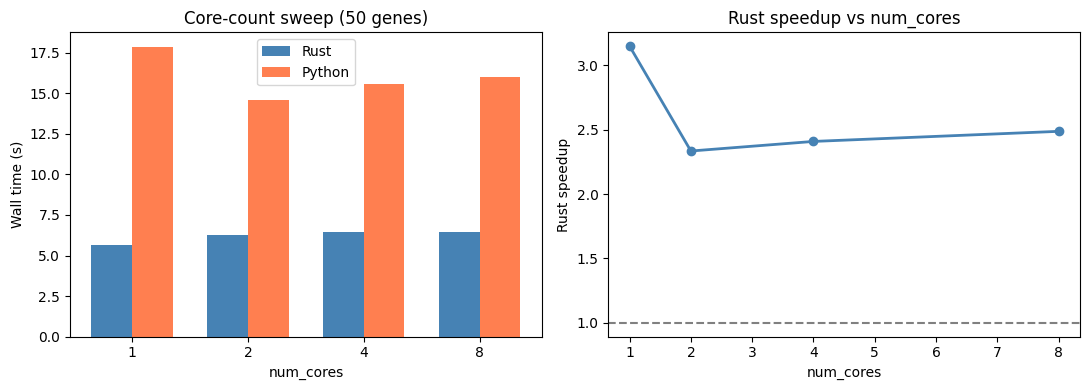

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rust_t   = [core_results[(nc, True)]  for nc in CORE_COUNTS]
python_t = [core_results[(nc, False)] for nc in CORE_COUNTS]
speedups = [core_results[(nc, False)] / core_results[(nc, True)] for nc in CORE_COUNTS]

x, w = np.arange(len(CORE_COUNTS)), 0.35
ax = axes[0]
ax.bar(x - w/2, rust_t,   w, label='Rust',   color='steelblue')
ax.bar(x + w/2, python_t, w, label='Python', color='coral')
ax.set_xticks(x); ax.set_xticklabels(CORE_COUNTS)
ax.set_xlabel('num_cores'); ax.set_ylabel('Wall time (s)')
ax.set_title(f'Core-count sweep ({N_GENES_CORE} genes)')
ax.legend()

ax = axes[1]
ax.plot(CORE_COUNTS, speedups, 'o-', color='steelblue', linewidth=2)
ax.axhline(1, linestyle='--', color='gray')
ax.set_xlabel('num_cores'); ax.set_ylabel('Rust speedup')
ax.set_title('Rust speedup vs num_cores')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout(); plt.show()

## 2. Gene-count sweep

Fixed `num_cores=4`; vary number of genes.

In [5]:
GENE_COUNTS  = [25, 50, 100, 200]
SWEEP_CORES  = 4
gene_results = {}

for n_genes in GENE_COUNTS:
    for has_rust in (True, False):
        print(f'n_genes={n_genes}, rust={has_rust} ...', end=' ', flush=True)
        t = time_full_pipeline(H5AD_PATH, n_genes, SWEEP_CORES, has_rust)
        gene_results[(n_genes, has_rust)] = t
        print(f'{t:.1f}s')


is sparse


5867 genes retained after expression filter.


n_genes=25, rust=True ... 

Grid scan:   0%|          | 0/12 [00:00<?, ?it/s]

Grid scan:   8%|▊         | 1/12 [00:00<00:04,  2.65it/s]

...

Grid scan:  83%|████████▎ | 10/12 [00:57<00:09,  4.78s/it]

Grid scan:  92%|█████████▏| 11/12 [01:01<00:04,  4.47s/it]

Grid scan: 100%|██████████| 12/12 [01:04<00:00,  4.26s/it]

Grid scan: 100%|██████████| 12/12 [01:04<00:00,  5.41s/it]

64.9s


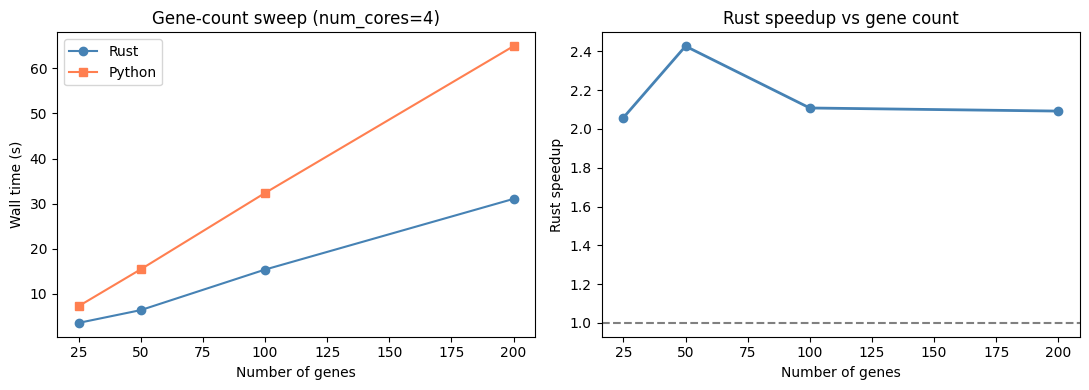

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gr_rust    = [gene_results[(n, True)]  for n in GENE_COUNTS]
gr_python  = [gene_results[(n, False)] for n in GENE_COUNTS]
gr_speedup = [gene_results[(n, False)] / gene_results[(n, True)] for n in GENE_COUNTS]

ax = axes[0]
ax.plot(GENE_COUNTS, gr_rust,   'o-', color='steelblue', label='Rust')
ax.plot(GENE_COUNTS, gr_python, 's-', color='coral',     label='Python')
ax.set_xlabel('Number of genes'); ax.set_ylabel('Wall time (s)')
ax.set_title(f'Gene-count sweep (num_cores={SWEEP_CORES})')
ax.legend()

ax = axes[1]
ax.plot(GENE_COUNTS, gr_speedup, 'o-', color='steelblue', linewidth=2)
ax.axhline(1, linestyle='--', color='gray')
ax.set_xlabel('Number of genes'); ax.set_ylabel('Rust speedup')
ax.set_title('Rust speedup vs gene count')
fig.tight_layout(); plt.show()

## 3. Cell-count sweep

Fixed `num_cores=4`, 50 genes; subsample cells to vary histogram density.
Top x-axis shows median PSS grid size at each cell count.

In [7]:
CELL_COUNTS  = [100, 500, 1000, 10000]
SWEEP_GENES  = 50
cell_results = {}  # (n_cells, has_rust) -> (elapsed, median_grid)

# Pre-create all subsampled temp files before timing,
# then free the full adata to avoid OOM during inference.
full_adata = ad.read_h5ad(H5AD_PATH)
rng = np.random.default_rng(0)
tmp_paths = {}
for n_cells in CELL_COUNTS:
    idx = rng.choice(full_adata.n_obs, size=min(n_cells, full_adata.n_obs), replace=False)
    sub = full_adata[idx].copy()
    with tempfile.NamedTemporaryFile(suffix='.h5ad', delete=False) as f:
        tmp_paths[n_cells] = f.name
    sub.write_h5ad(tmp_paths[n_cells])
    del sub
del full_adata

for n_cells in CELL_COUNTS:
    tmp = tmp_paths[n_cells]
    # Probe M values (outside the timed region).
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        adata_probe = extract_data(tmp, MODEL,
            dataset_name='pbmc_probe',
            modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
            n_genes=SWEEP_GENES, hist_type='unique', viz=False)
    median_grid = int(np.median(adata_probe.uns['M'][0] * adata_probe.uns['M'][1]))
    del adata_probe
    for has_rust in (True, False):
        print(f'n_cells={n_cells}, rust={has_rust} (median grid={median_grid}) ...', end=' ', flush=True)
        t = time_full_pipeline(tmp, SWEEP_GENES, SWEEP_CORES, has_rust)
        cell_results[(n_cells, has_rust)] = (t, median_grid)
        print(f'{t:.1f}s')
    os.unlink(tmp)


is sparse
1157 genes retained after expression filter.
n_cells=100, rust=True (median grid=289) ... 

Grid scan:   0%|          | 0/12 [00:00<?, ?it/s]

Grid scan:   8%|▊         | 1/12 [00:00<00:07,  1.50it/s]

Grid scan:  17%|█▋        | 2/12 [00:01<00:07,  1.42it/s]

Grid scan:  25%|██▌       | 3/12 [00:01<00:05,  1.54it/s]

...

Grid scan:  83%|████████▎ | 10/12 [00:15<00:02,  1.32s/it]

Grid scan:  92%|█████████▏| 11/12 [00:16<00:01,  1.17s/it]

Grid scan: 100%|██████████| 12/12 [00:17<00:00,  1.14s/it]

Grid scan: 100%|██████████| 12/12 [00:17<00:00,  1.43s/it]

17.2s


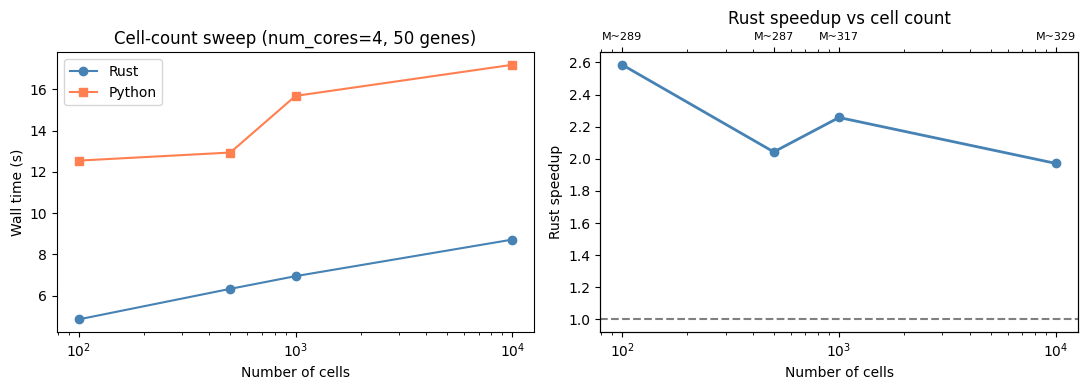

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cr_rust    = [cell_results[(n, True)][0]  for n in CELL_COUNTS]
cr_python  = [cell_results[(n, False)][0] for n in CELL_COUNTS]
cr_speedup = [cell_results[(n, False)][0] / cell_results[(n, True)][0] for n in CELL_COUNTS]
cr_grids   = [cell_results[(n, True)][1]  for n in CELL_COUNTS]

ax = axes[0]
ax.plot(CELL_COUNTS, cr_rust,   'o-', color='steelblue', label='Rust')
ax.plot(CELL_COUNTS, cr_python, 's-', color='coral',     label='Python')
ax.set_xscale('log')
ax.set_xlabel('Number of cells'); ax.set_ylabel('Wall time (s)')
ax.set_title(f'Cell-count sweep (num_cores={SWEEP_CORES}, {SWEEP_GENES} genes)')
ax.legend()

ax = axes[1]
ax.set_xscale('log')
ax.plot(CELL_COUNTS, cr_speedup, 'o-', color='steelblue', linewidth=2)
ax.axhline(1, linestyle='--', color='gray')
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(CELL_COUNTS)
ax2.set_xticklabels([f'M~{g}' for g in cr_grids], fontsize=8)
ax.set_xlabel('Number of cells'); ax.set_ylabel('Rust speedup')
ax.set_title('Rust speedup vs cell count')
fig.tight_layout(); plt.show()